# Figure 4 — cumulative CDR over time vs feedstock dissolved potential

Data: `site_cdr.zarr` (`figures/postprocess-data/create-site-co2.ipynb`).

## 0. Setup — everything the figures show is chosen here

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke

# ============================ what to plot ==============================
SITE1 = "Kuma"        # the three panels, left to right
SITE2 = "Palouse"
SITE3 = "Pullman"
PLANE = 100              # control plane depth in cm; one of 50, 100, 200, 300
CASES_SHOWN = ["hourly", "daily", "monthly", "longterm"]   # any non-empty subset
DIFF_CASE = "longterm"   # figure 4c only: its bars are DIFF_CASE minus REFERENCE, and it
                         # draws that pair of curves alone, whatever CASES_SHOWN holds
STRIP_SHARE_X = True     # one dissolution scale across the three strips of figure 4a.
                         # False scales each strip to its own site
# ========================================================================

# ----------------------------------------------------------------- knobs
PANEL_W, PANEL_H = 3.6, 3.9   # inches, the timeseries panel
BAR_W = 1.9            # inches, figure 4b's second column
STRIP_H = 0.55         # inches, figure 4a's pearl row
PEARL_SIZE = 6.5       # points, the pearl. 
LETTER_GAP = 0.045     # closest two letters may sit, as a fraction of the strip's x span
SHARE_Y = True         # one y scale per quantity -- the three sites are meant to be compared
SHOW_TITLE = False
SAVE = False           # write figures/fig4{b,e}-new.{pdf,png}
DPI = 600              # raster fallback; PDF is vector
LABEL_MARGIN = 0.20    # right-hand margin for the direct labels, as a fraction of the x span
LABEL_GAP = 0.055      # minimum vertical gap between direct labels, as a fraction of the y span
LINE_W = 1.6
BAR_HEADROOM = 0.15    # room for the value labels above the bars
# ------------------------------------------------------------------------

REFERENCE = "hourly"   # drawn as the reference: neutral and dashed, never a step of the blue ramp
YEAR_DAYS = 365        # this calendar has no leap days

STORE = ("s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations"
         "/postprocessed/met_forcing_rxn/site_cdr.zarr")
FIGDIR = Path("")      # where to save if SAVE = True

In [2]:
# --- colour ------------------------------------------------------------------
CASE_COLOR = {"hourly": "#6b6b6b", "daily": "#3f8fe3",
              "monthly": "#1857a9", "longterm": "#0c2d61"}
CASE_STYLE = {"hourly": (0, (4, 1.6))}          # everything not named here is solid

POTENTIAL_COLOR = "#c1741a"                     # figure 4c: potential, off the case ramp
FILL_ALPHA = 0.22                               # bar fills, as in fig4
INK, MUTED = "#1a1a1a", "#5c5c5c"               # text tokens; never a series colour on text
HALO = [withStroke(linewidth=2.2, foreground="white")]

# --- print rc ----------------------------------------------------------------
PUB_RC = {
    "font.family": "sans-serif",
}

## 1. Read the store

In [3]:
ds = xr.open_zarr(STORE).load()

SITES_AVAILABLE = [str(s) for s in ds["site"].values]
CASES_AVAILABLE = [str(c) for c in ds["case"].values]      # canonical order: coarse-ward
PLANES_AVAILABLE = [int(p) for p in ds["plane"].values]


def check(name, value, allowed):
    if value not in allowed:
        raise ValueError(f"{name} = {value!r} is not in the store. Available: {allowed}")
    return value


SITES = [check(f"SITE{i}", s, SITES_AVAILABLE)
         for i, s in enumerate((SITE1, SITE2, SITE3), start=1)]
check("PLANE", PLANE, PLANES_AVAILABLE)
if len(set(SITES)) < len(SITES):
    print(f"note: {SITES} repeats a site; those panels will be identical")

# Canonical order, duplicates dropped.
SHOWN = [c for c in CASES_AVAILABLE if c in set(CASES_SHOWN)]
if not SHOWN:
    raise ValueError(f"CASES_SHOWN is empty. Available: {CASES_AVAILABLE}")
for c in CASES_SHOWN:
    check("CASES_SHOWN", c, CASES_AVAILABLE)
# (store already carbonate corrected)
if not ds.attrs.get("carbonate_corrected"):
    raise ValueError(
        f"{STORE.rsplit('/', 1)[-1]} is not carbonate-corrected. Re-run "
        "figures/postprocess-data/create-site-co2.ipynb, or draw `cdr - carbonate_c` instead.")

cdr = ds["cdr"].sel(plane=PLANE)
YEARS = ds["time"].values / YEAR_DAYS               # the x axis, in years since the amendment
X_END = float(YEARS[-1])
STATE = {s: str(ds["state"].sel(site=s).values) for s in SITES_AVAILABLE}
CEILING = float(ds["cdr_potential"].sel(site=SITES[0]))
assert np.allclose(ds["cdr_potential"].values, CEILING), "sites differ in CDR potential"

# the share of the applied feedstock dissolved by year 10
_fm = ds["forsterite_mass"]
DISS_FRAC = (100 * (1 - _fm.isel(time=-1) / _fm.isel(time=0))).to_pandas()
FINAL = cdr.isel(time=-1).to_pandas()

print(f"store   : {STORE.rsplit('/', 1)[-1]}   {dict(ds.sizes)}   carbonate-corrected")
print(f"sites   : {', '.join(f'{s} ({STATE[s]})' for s in SITES)}")
print(f"plane   : {PLANE} cm of {PLANES_AVAILABLE}")
print(f"cases   : {', '.join(SHOWN)}  (of {', '.join(CASES_AVAILABLE)})")
print(f"CDR at complete conversion of the applied feedstock: {CEILING:.2f} t CO2/ha\n")
for site in SITES:
    print(f"  {site} ({STATE[site]})")
    for c in SHOWN:
        print(f"    {c:9s} CDR {FINAL.loc[site, c]:+6.3f} t CO2/ha   "
              f"{100 * FINAL.loc[site, c] / CEILING:+6.1f}% of the ceiling   "
              f"{DISS_FRAC.loc[site, c]:5.1f}% of the feedstock dissolved")

store   : site_cdr.zarr   {'site': 8, 'case': 4, 'plane': 4, 'time': 3651}   carbonate-corrected
sites   : Kuma (Eastern CO), Palouse (Eastern WA), Pullman (Northern TX)
plane   : 100 cm of [50, 100, 200, 300]
cases   : hourly, daily, monthly, longterm  (of hourly, daily, monthly, longterm)
CDR at complete conversion of the applied feedstock: 12.30 t CO2/ha

  Kuma (Eastern CO)
    hourly    CDR +2.606 t CO2/ha    +21.2% of the ceiling    57.9% of the feedstock dissolved
    daily     CDR +2.593 t CO2/ha    +21.1% of the ceiling    58.0% of the feedstock dissolved
    monthly   CDR +2.613 t CO2/ha    +21.2% of the ceiling    59.7% of the feedstock dissolved
    longterm  CDR +2.790 t CO2/ha    +22.7% of the ceiling    65.2% of the feedstock dissolved
  Palouse (Eastern WA)
    hourly    CDR +2.205 t CO2/ha    +17.9% of the ceiling    85.8% of the feedstock dissolved
    daily     CDR +2.185 t CO2/ha    +17.8% of the ceiling    85.5% of the feedstock dissolved
    monthly   CDR +2.490 t

## 2. Shared drawing helpers

In [4]:
XPOS = np.arange(len(SHOWN), dtype=float)


def spread(values, gap):
    """Label positions: `values` nudged apart so consecutive ones are at least `gap` apart.

    Fed a descending list. Each label is placed at its true value unless the one above has
    already claimed that space, in which case it drops to just below it. 
    """
    out = []
    for v in values:
        out.append(v if not out else min(v, out[-1] - gap))
    return out


def draw_timeseries(ax, site, xlabel=True, cases=None):
    """One site's CDR curves, one per selected case; `cases` narrows it to a subset."""
    for case in (cases or SHOWN):
        ax.plot(YEARS, cdr.sel(site=site, case=case).values,
                color=CASE_COLOR[case], lw=LINE_W, ls=CASE_STYLE.get(case, "-"),
                solid_joinstyle="round", zorder=4, label=case)

    ax.axhline(0, color=MUTED, lw=0.8, zorder=3)      # CDR can go negative; the sign matters
    ax.set_xlim(0, X_END * (1 + LABEL_MARGIN))
    ax.set_xticks(np.arange(0, X_END + 1, 2))
    if xlabel:
        ax.set_xlabel("years since the amendment")
    ax.set_ylabel(f"cumulative CDR past {PLANE} cm  (t CO$_2$ ha$^{{-1}}$)")


def label_curves(ax, site, cases=None):
    """Direct-label every drawn case in the right-hand margin, in curve order."""
    cases = cases or SHOWN
    lo, hi = ax.get_ylim()
    gap = LABEL_GAP * (hi - lo)
    ends = {c: float(cdr.sel(site=site, case=c).values[-1]) for c in cases}
    order = sorted(cases, key=lambda c: -ends[c])
    for case, y in zip(order, spread([ends[c] for c in order], gap)):
        ax.annotate(case, xy=(X_END, ends[case]), xytext=(X_END * 1.03, y),
                    textcoords="data", ha="left", va="center",
                    color=CASE_COLOR[case], fontsize=7, path_effects=HALO, zorder=6,
                    annotation_clip=False)


def annotate_bars(ax, xs, values, colors, fmt, rotation):
    """A number on every bar. Rotate where the panel is narrower than the labels are wide."""
    lo, hi = ax.get_ylim()
    pad = 0.02 * (hi - lo)
    for x, v, color in zip(xs, values, colors):
        ax.text(x, v + (pad if v >= 0 else -pad), fmt.format(v), rotation=rotation,
                ha="center", va="bottom" if v >= 0 else "top",
                fontsize=6.5, color=color, path_effects=HALO, zorder=6)


def case_legend(ax, cases=None):
    ax.legend(handles=[Line2D([], [], color=CASE_COLOR[c], lw=LINE_W,
                              ls=CASE_STYLE.get(c, "-"), label=c)
                       for c in (cases or SHOWN)],
              title="met forcing", loc="best", handlelength=2.0, borderaxespad=0.6,
              labelcolor=INK, framealpha=0.9, fontsize=7, title_fontsize=7)


def unify_y(axes):
    """One y scale across a group of axes: the union of what each autoscaled to."""
    lo = min(ax.get_ylim()[0] for ax in axes)
    hi = max(ax.get_ylim()[1] for ax in axes)
    for ax in axes:
        ax.set_ylim(lo, hi)


def panel_tag(ax, tag):
    ax.text(0.02, 0.985, tag, transform=ax.transAxes, ha="left", va="top",
            fontsize=9, fontweight="bold", color=INK, path_effects=HALO, zorder=7)


def save(fig, stem):
    if not SAVE:
        return
    for ext in ("pdf", "png"):
        fig.savefig(FIGDIR / f"{stem}.{ext}", dpi=DPI, bbox_inches="tight")
    print("wrote", ", ".join(str(FIGDIR / f"{stem}.{e}") for e in ("pdf", "png")))

## 3. Figure 4a — three sites + dissolution strips


feedstock dissolved by year 10 (%), the pearls:

case        hourly      daily    monthly   longterm
site                                               
Kuma     57.900002  57.959999  59.740002  65.220001
Palouse  85.809998  85.540001  87.080002  88.180000
Pullman  46.110001  45.970001  45.090000  43.459999

strip scale: shared
  Kuma            57.9 -  65.2%   spread  7.3   most under longterm
  Palouse         85.5 -  88.2%   spread  2.6   most under longterm
  Pullman         43.5 -  46.1%   spread  2.7   most under hourly


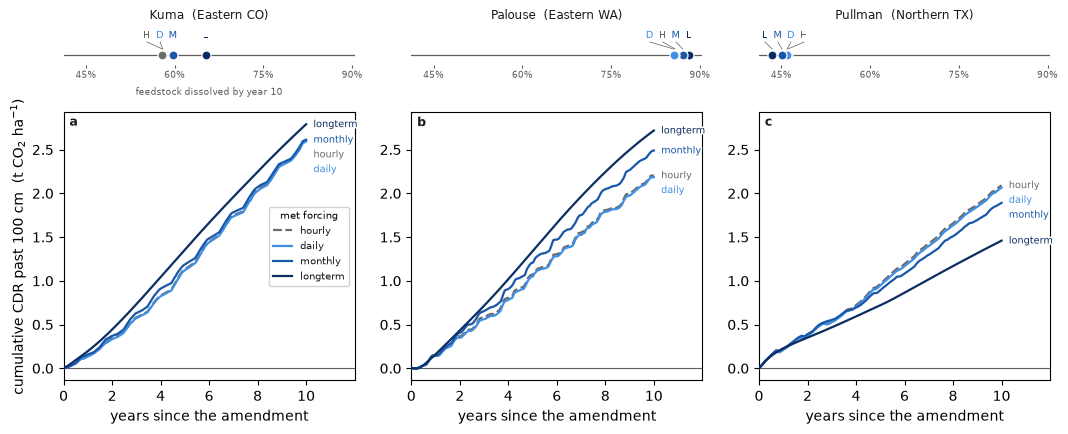

In [5]:
CASE_LETTER = {c: c[0].upper() for c in SHOWN}                # hourly H, daily D, monthly M ...
if len(set(CASE_LETTER.values())) < len(SHOWN):               # ... unless two cases share one
    CASE_LETTER = {c: c[:2].capitalize() for c in SHOWN}


def strip_limits(sites):
    """The strip's x range. Padded by widest spread."""
    vals = [DISS_FRAC.loc[s, c] for s in sites for c in SHOWN]
    widest = max(DISS_FRAC.loc[s, SHOWN].max() - DISS_FRAC.loc[s, SHOWN].min() for s in SITES)
    lo, hi = min(vals), max(vals)
    pad = max(0.30 * widest, 0.05 * (hi - lo), 0.5)
    return lo - pad, hi + pad


def draw_pearls(ax, site, xlim, xlabel=False):
    """Pearls on a string: where each of a site's cases falls on the dissolution line."""
    span = xlim[1] - xlim[0]
    ax.set_xlim(*xlim)
    ax.set_ylim(-0.45, 1.3)
    ax.plot(xlim, [0, 0], color=MUTED, lw=0.9, solid_capstyle="round", zorder=2)

    # Two cases can sit a tenth of a point apart, so the letters are spread the way the curve
    # labels are, then shifted back inside the axis; a nudged letter keeps a leader to its pearl.
    order = sorted(SHOWN, key=lambda c: -DISS_FRAC.loc[site, c])
    xs = [DISS_FRAC.loc[site, c] for c in order]
    at = spread(xs, LETTER_GAP * span)
    at = [x + max(0.0, xlim[0] + 0.02 * span - min(at)) for x in at]
    for case, x, xtext in zip(order, xs, at):
        ax.plot([x], [0], marker="o", ms=PEARL_SIZE, color=CASE_COLOR[case],
                markeredgecolor="white", markeredgewidth=0.9, zorder=5, clip_on=False)
        if abs(xtext - x) > 1e-9 * span:
            ax.plot([x, xtext], [0.30, 0.62], color=MUTED, lw=0.5, zorder=3)
        ax.text(xtext, 0.70, CASE_LETTER[case], ha="center", va="bottom", fontsize=7,
                color=CASE_COLOR[case], path_effects=HALO, zorder=6)

    ax.set_yticks([])
    ax.grid(False)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.tick_params(axis="x", length=2.5, pad=1.5, labelsize=6.5, colors=MUTED)
    if xlabel:
        ax.set_xlabel("feedstock dissolved by year 10", fontsize=6.5, color=MUTED, labelpad=5)


with plt.rc_context(PUB_RC):
    fig_e, grid = plt.subplots(
        2, len(SITES), figsize=(len(SITES) * PANEL_W, PANEL_H + STRIP_H),
        gridspec_kw={"height_ratios": [STRIP_H, PANEL_H]})

    shared = strip_limits(SITES)
    for col, site in enumerate(SITES):
        draw_pearls(grid[0, col], site, shared if STRIP_SHARE_X else strip_limits([site]),
                    xlabel=col == 0)
        # The strip sits under the site name, so the name goes on the strip, not on the panel.
        grid[0, col].set_title(f"{site}  ({STATE[site]})", color=INK, fontsize=8.5)
        draw_timeseries(grid[1, col], site)

    if SHARE_Y:
        unify_y(grid[1, :])
        for ax in grid[1, 1:]:
            ax.set_ylabel("")             # one label serves the row when the scale is shared

    for col, (site, tag) in enumerate(zip(SITES, "abcdef")):
        label_curves(grid[1, col], site)
        panel_tag(grid[1, col], tag)
    case_legend(grid[1, 0])

    if SHOW_TITLE:
        fig_e.suptitle(f"Cumulative CDR past {PLANE} cm, over the feedstock each run dissolved",
                       x=0.02, ha="left", color=INK)
    fig_e.tight_layout()
    save(fig_e, "fig4e-new")

print(f"feedstock dissolved by year {X_END:.0f} (%), the pearls:\n")
print(DISS_FRAC.loc[SITES, SHOWN].round(2).to_string())
print(f"\nstrip scale: {'shared' if STRIP_SHARE_X else 'per site'}")
for site in SITES:
    row = DISS_FRAC.loc[site, SHOWN]
    print(f"  {site:14s} {row.min():5.1f} - {row.max():5.1f}%   spread {row.max() - row.min():4.1f}"
          f"   most under {row.idxmax()}")
plt.show()

## 4. Figure 4b — the same three sites, dissolution as bars

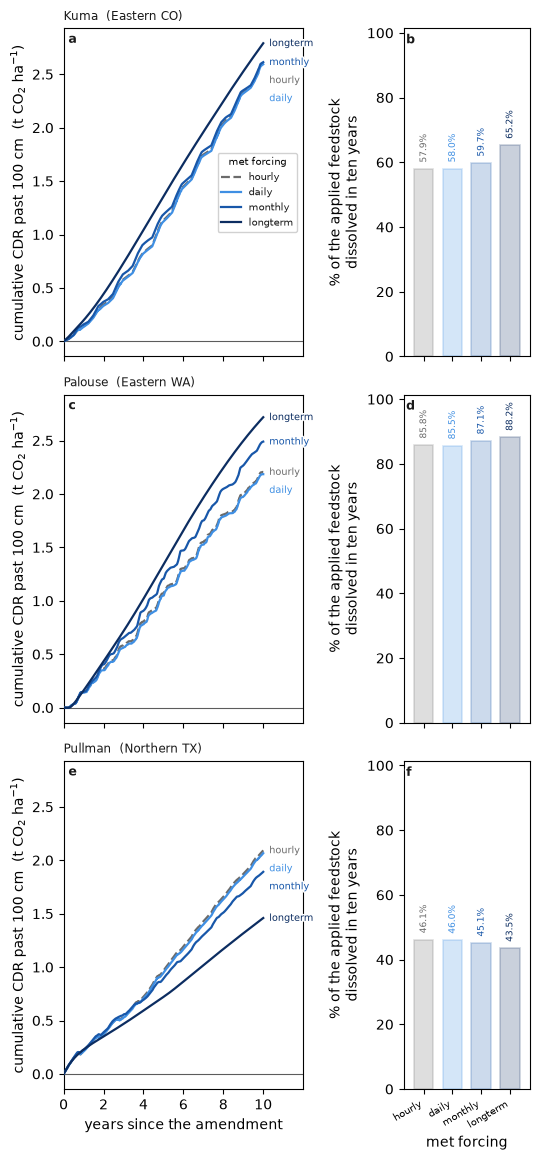

In [6]:
def draw_diss_bars(ax, site, xlabel=True):
    """One bar per case: the share of the applied feedstock this run dissolved in ten years."""
    for x, case in zip(XPOS, SHOWN):
        ax.bar(x, DISS_FRAC.loc[site, case], width=0.68, color=CASE_COLOR[case],
               alpha=FILL_ALPHA, edgecolor=CASE_COLOR[case], lw=1.2, zorder=2)

    ax.set_xticks(XPOS)
    ax.set_xticklabels(SHOWN, rotation=30, ha="right", fontsize=7)
    ax.set_xlim(XPOS[0] - 0.7, XPOS[-1] + 0.7)
    if xlabel:
        ax.set_xlabel("met forcing")
    ax.set_ylabel("% of the applied feedstock\ndissolved in ten years")
    # A share of a whole, so the baseline is zero and the head is 100 -- not the autoscale.
    ax.set_ylim(0, min(100.0, DISS_FRAC.loc[SITES, SHOWN].to_numpy().max()) * (1 + BAR_HEADROOM))


with plt.rc_context(PUB_RC):
    fig_b, grid = plt.subplots(
        len(SITES), 2, figsize=(PANEL_W + BAR_W, len(SITES) * PANEL_H),
        gridspec_kw={"width_ratios": [PANEL_W, BAR_W]},
        sharex="col", sharey="col" if SHARE_Y else False)

    for row, site in enumerate(SITES):
        bottom = row == len(SITES) - 1
        draw_timeseries(grid[row, 0], site, xlabel=bottom)
        draw_diss_bars(grid[row, 1], site, xlabel=bottom)
        # The site names the row, so it sits on the row's leading panel only.
        grid[row, 0].set_title(f"{site}  ({STATE[site]})", color=INK, fontsize=8.5, loc="left")

    if SHARE_Y:
        unify_y(grid[:, 0])

    for row, site in enumerate(SITES):
        label_curves(grid[row, 0], site)
        # Upright labels: the bar panel is narrow and a horizontal "94.5%" is wider than the bar
        # it belongs to, so flat labels collide as soon as two neighbouring cases are close.
        annotate_bars(grid[row, 1], XPOS, [DISS_FRAC.loc[site, c] for c in SHOWN],
                      [CASE_COLOR[c] for c in SHOWN], "{:.1f}%", rotation=90)
    for ax, tag in zip(grid.ravel(), "abcdefghij"):
        panel_tag(ax, tag)
    case_legend(grid[0, 0])

    if SHOW_TITLE:
        fig_b.suptitle(f"Cumulative CDR past {PLANE} cm, and the feedstock each run dissolved",
                       x=0.02, ha="left", color=INK)
    fig_b.tight_layout()
    save(fig_b, "fig4b-new")

plt.show()

## 5. Figure 4c — D_diss and D_CDR

| bar | explanation |
|---|---|
| **potential** | the change in cumulative *potential* CDR over 10 years from the change in dissolution (long-term minus hourly) |
| **exported** | the change in cumulative *actual* CDR over 10 years |

longterm minus hourly at year 10, t CO2/ha (potential is plane-independent, exported is past 100 cm):

  Kuma           potential +0.900   exported +0.185   exported change is  +20.5% of the potential change
  Palouse        potential +0.292   exported +0.513   exported change is +175.7% of the potential change
  Pullman        potential -0.327   exported -0.633   exported change is +193.8% of the potential change


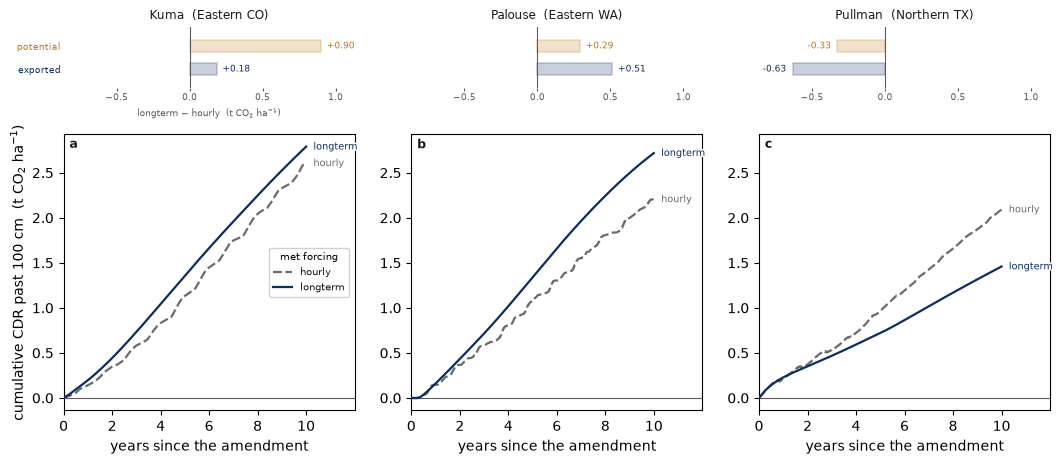

In [30]:
# ----------------------------------------------------------------- knobs
BARS_H = 0.85          # inches, the two-bar row above each timeseries
BAR_THICK = 0.52       # bar thickness, in the row's own units -- the bars sit at y = 1 and y = 0
# ------------------------------------------------------------------------

check("DIFF_CASE", DIFF_CASE, CASES_AVAILABLE)
if DIFF_CASE == REFERENCE:
    raise ValueError(f"DIFF_CASE and REFERENCE are both {REFERENCE!r}; every bar would be zero")
PAIR = [REFERENCE, DIFF_CASE]        # the only cases drawn: the bars are their difference

# Potential CDR, per run: the feedstock that run dissolved, at 4 eq of alkalinity per mole and
# 1 mol CO2 per eq -- the same conversion the store applies to the day-0 inventory to get
# `cdr_potential`, so it is that ceiling scaled by the fraction dissolved.
POTENTIAL = DISS_FRAC / 100 * CEILING                        # (site, case), t CO2/ha
DIFF_POT = POTENTIAL[DIFF_CASE] - POTENTIAL[REFERENCE]       # (site,), the top bar
DIFF = FINAL[DIFF_CASE] - FINAL[REFERENCE]                   # (site,), the bottom bar

# Top bar first. `potential` gets its own colour; `exported` keeps the coarsened case's, so it
# reads as that curve's endpoint moving.
BAR_ROWS = [("potential", DIFF_POT, POTENTIAL_COLOR),
            ("exported", DIFF, CASE_COLOR[DIFF_CASE])]


def change_limits():
    """One x range for all six bars -- the three panels are meant to be read against each other.

    Zero is always in it: it is the baseline the bars are read against, and both can fall either
    side of it.
    """
    vals = [float(series[s]) for _, series, _ in BAR_ROWS for s in SITES] + [0.0]
    lo, hi = min(vals), max(vals)
    return lo - BAR_HEADROOM * (hi - lo), hi + BAR_HEADROOM * (hi - lo)


def draw_change_bars(ax, site, xlim, ylabel=False, xlabel=False):
    """Two horizontal bars: what coarsening did to the potential, and what it did to the export."""
    pad = 0.02 * (xlim[1] - xlim[0])
    ax.set_xlim(*xlim)
    ax.set_ylim(-0.8, 1.8)
    for y, (name, series, color) in zip((1, 0), BAR_ROWS):
        v = float(series[site])
        ax.barh(y, v, height=BAR_THICK, color=color, alpha=FILL_ALPHA,
                edgecolor=color, lw=1.2, zorder=2)
        ax.text(v + (pad if v >= 0 else -pad), y, f"{v:+.2f}",
                ha="left" if v >= 0 else "right", va="center",
                fontsize=6.5, color=color, path_effects=HALO, zorder=6)
    ax.axvline(0, color=MUTED, lw=0.8, zorder=3)

    ax.grid(False)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    if ylabel:
        # Named on the leading panel only; the colours carry the mapping in the other two.
        ax.set_yticks([1, 0])
        ax.set_yticklabels([r[0] for r in BAR_ROWS], fontsize=6.5)
        for tick, row in zip(ax.get_yticklabels(), BAR_ROWS):
            tick.set_color(row[2])
        ax.tick_params(axis="y", length=0, pad=2)
    else:
        ax.set_yticks([])
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.tick_params(axis="x", length=2.5, pad=1.5, labelsize=6.5, colors=MUTED)
    if xlabel:
        ax.set_xlabel(f"{DIFF_CASE} $-$ {REFERENCE}  (t CO$_2$ ha$^{{-1}}$)",
                      fontsize=6.5, color=MUTED, labelpad=4)


with plt.rc_context(PUB_RC):
    fig_c, grid = plt.subplots(
        2, len(SITES), figsize=(len(SITES) * PANEL_W, PANEL_H + BARS_H),
        gridspec_kw={"height_ratios": [BARS_H, PANEL_H]})

    xlim = change_limits()
    for col, site in enumerate(SITES):
        draw_change_bars(grid[0, col], site, xlim, ylabel=col == 0, xlabel=col == 0)
        # The bars sit under the site name, so the name goes on them, not on the panel.
        grid[0, col].set_title(f"{site}  ({STATE[site]})", color=INK, fontsize=8.5)
        draw_timeseries(grid[1, col], site, cases=PAIR)

    if SHARE_Y:
        unify_y(grid[1, :])
        for ax in grid[1, 1:]:
            ax.set_ylabel("")             # one label serves the row when the scale is shared

    for col, (site, tag) in enumerate(zip(SITES, "abcdef")):
        label_curves(grid[1, col], site, cases=PAIR)
        panel_tag(grid[1, col], tag)
    case_legend(grid[1, 0], cases=PAIR)

    if SHOW_TITLE:
        fig_c.suptitle(f"Coarsening to {DIFF_CASE}: what it dissolves, and what reaches {PLANE} cm",
                       x=0.02, ha="left", color=INK)
    fig_c.tight_layout()
    save(fig_c, "fig4c")

print(f"{DIFF_CASE} minus {REFERENCE} at year {X_END:.0f}, t CO2/ha "
      f"(potential is plane-independent, exported is past {PLANE} cm):\n")
for site in SITES:
    dp, dc = float(DIFF_POT[site]), float(DIFF[site])
    share = f"{100 * dc / dp:+6.1f}%" if abs(dp) > 1e-9 else "   n/a"
    print(f"  {site:14s} potential {dp:+6.3f}   exported {dc:+6.3f}   "
          f"exported change is {share} of the potential change")
plt.show()

## 6. Numbers

In [7]:
rows = []
for site in SITES:
    for case in SHOWN:
        series = cdr.sel(site=site, case=case).values
        rows.append({
            "site": site, "case": case,
            "CDR at yr 10": series[-1],
            "% of the ceiling": 100 * series[-1] / CEILING,
            "% feedstock dissolved": DISS_FRAC.loc[site, case],
            "forsterite left (t/ha)": float(_fm.sel(site=site, case=case).values[-1]),
            "carbonate correction": float(ds["carbonate_c"].sel(site=site, case=case, plane=PLANE)
                                          .values[-1]),
            "peak": series.max(), "trough": series.min()})

print(f"plane {PLANE} cm, year {X_END:.0f}; t CO2/ha except where noted. The ceiling is "
      f"{CEILING:.3f} t CO2/ha at complete conversion of the {float(_fm.isel(time=0).values.max()):.3f}"
      f" t/ha applied.\n")
display(pd.DataFrame(rows).set_index(["site", "case"]).round(3))

print(f"\ncoarsening the forcing from {REFERENCE} to {SHOWN[-1]}:\n")
display(pd.DataFrame({
    "CDR change": FINAL.loc[SITES, SHOWN[-1]] - FINAL.loc[SITES, REFERENCE],
    "dissolution change (pts)": (DISS_FRAC.loc[SITES, SHOWN[-1]]
                                 - DISS_FRAC.loc[SITES, REFERENCE])}).round(3)
        if REFERENCE in SHOWN else f"{REFERENCE} is not in CASES_SHOWN")

plane 100 cm, year 10; t CO2/ha except where noted. The ceiling is 12.304 t CO2/ha at complete conversion of the 9.833 t/ha applied.



CDR at yr 10  % of the ceiling  % feedstock dissolved  \
site    case                                                              
Palouse hourly           2.205         17.924000              85.805000   
        daily            2.185         17.760000              85.541000   
        monthly          2.490         20.238001              87.077003   
        longterm         2.718         22.093000              88.177002   
Cecil   hourly           0.560          4.554000              94.458000   
        daily            0.571          4.643000              94.502998   
        monthly          0.794          6.455000              95.488998   
        longterm         0.970          7.885000              96.081001   
Pullman hourly           2.093         17.007999              46.112999   
        daily            2.066         16.792000              45.974998   
        monthly          1.892         15.374000              45.089001   
        longterm         1.459         11.861000              43.458000   

                  forsterite left (t/ha)  carbonate correction   peak  trough  
site    case                                                                   
Palouse hourly                     1.396                 0.000  2.206  -0.001  
        daily                      1.422                 0.000  2.186  -0.001  
        monthly                    1.271                 0.000  2.490  -0.002  
        longterm                   1.163                 0.000  2.718  -0.002  
Cecil   hourly                     0.545                 0.000  0.560  -0.000  
        daily                      0.541                 0.000  0.571  -0.000  
        monthly                    0.444                 0.000  0.794  -0.000  
        longterm                   0.385                 0.000  0.970  -0.000  
Pullman hourly                     5.299                -2.805  2.093   0.000  
        daily                      5.313                -2.794  2.066   0.000  
        monthly                    5.400                -2.758  1.892   0.000  
        longterm                   5.560                -2.971  1.459   0.000


coarsening the forcing from hourly to longterm:



,CDR change,dissolution change (pts)
site,,
Palouse,0.513,2.372
Cecil,0.410,1.623
Pullman,-0.633,-2.655


In [ ]:
# ---